<a href="https://colab.research.google.com/github/NgocPhuongAnna/Electric-Vehicle-Analysis/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Q1: How has the EV market evolved in terms of adoption volume and battery technology (Electric Range) over the last decade?
# Q2: Which manufacturers are leading the market, and how is their market share shifting between established hubs and developing regions?
# Q3: Which geographic segments represent high-potential but underserved markets for future infrastructure investment?
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from google.colab import drive
import os
!pip install openpyxl

#Import data
drive.mount('/content/drive')
os.path.exists('/content/drive/MyDrive/Electric_Vehicle_Population_Data_2026.csv')
#Check number of duplicates data
ev_df = pd.read_csv('/content/drive/MyDrive/Electric_Vehicle_Population_Data_2026.csv')
num_duplicates = len(ev_df[ev_df.duplicated()])
print(f"Duplicate data: {num_duplicates}")
print("Dataset shape:", ev_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Duplicate data: 0
Dataset shape: (279780, 16)


In [ ]:
# @title Code to put number into the graph
def add_labels(ax):
    for rect in ax.patches:
        width = rect.get_width()
        height = rect.get_height()

        if width > height:
            val = width

            ax.annotate(f'{int(val):,}',
                        (width, rect.get_y() + height / 2),
                        xytext=(5, 0),
                        textcoords="offset points",
                        ha='left', va='center',
                        fontsize=10, fontweight='bold')
        else:
            val = height
            ax.annotate(f'{int(val):,}',
                        (rect.get_x() + width / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold')

In [ ]:
#Data inspection
ev_df.info()
ev_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [ ]:
#5 first row of data
head = ev_df.head()
print(f"Frist five row: \n{head}")

Frist five row: 
   VIN (1-10)    County      City State  Postal Code  Model Year    Make  \
0  JN1AZ0CP5C   Stevens  Colville    WA      99114.0        2012  NISSAN   
1  JTMABABA7P    Yakima    Yakima    WA      98903.0        2023  SUBARU   
2  1N4AZ1CP1J      King   Seattle    WA      98122.0        2018  NISSAN   
3  5UX43EU09S    Kitsap   Poulsbo    WA      98370.0        2025     BMW   
4  3C3CFFGE5F  Thurston      Yelm    WA      98597.0        2015    FIAT   

      Model                   Electric Vehicle Type  \
0      LEAF          Battery Electric Vehicle (BEV)   
1  SOLTERRA          Battery Electric Vehicle (BEV)   
2      LEAF          Battery Electric Vehicle (BEV)   
3        X5  Plug-in Hybrid Electric Vehicle (PHEV)   
4       500          Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            73.0   
1  Eligibility unknown as battery range has not b..

The code here show 5 rows of begin of data

In [ ]:
#number of row and columns in data
num_row = ev_df.shape[0]
num_columns = ev_df.shape[1]
#Name of each column
data_name = ev_df.columns
print(f"Number of row: {num_row}")
print(f"Number of columns: {num_columns}")
print(f"Name of each column: {data_name}")

Number of row: 279780
Number of columns: 16
Name of each column: Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


The files have total 16 collumns and 271113 rows of data

In [ ]:
#Findout how many data missing in each column
num_data_missing = ev_df.isnull().sum()
#Data cleaning
ev_df['Electric Range'] = ev_df['Electric Range'].fillna(np.nan)
ev_df['Legislative District'] = ev_df['Legislative District'].fillna(np.nan)
ev_df['Vehicle Location'] = ev_df['Vehicle Location'].fillna(np.nan)
ev_df['Electric Utility'] = ev_df['Electric Utility'].fillna(np.nan)
ev_df['2020 Census Tract'] = ev_df['2020 Census Tract'].fillna(np.nan)
ev_df = ev_df.dropna(subset=['City', 'County', 'Postal Code','Electric Range', 'Vehicle Location'])
cleaned_missing_values = ev_df.isnull().sum()
print("Missing Values after clean:")
print(cleaned_missing_values)

Missing Values after clean:
VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


Find and clean missing data with fillna to get the best number and result

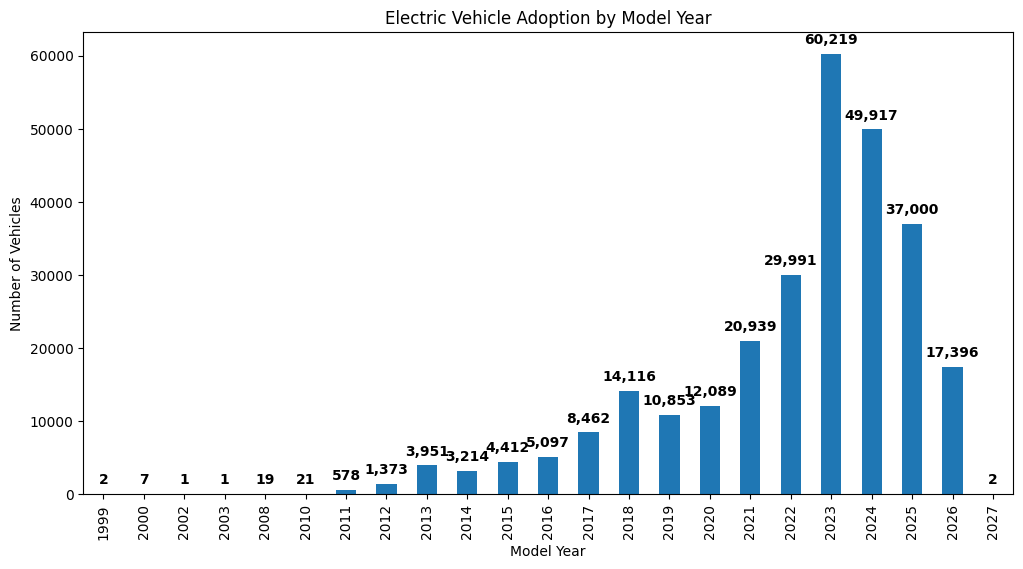

In [ ]:
# Bar graph to show which model year customers often use and this is the data drive to the answer for Q1

ev_by_year = ev_df.groupby("Model Year").size()
fig, ax = plt.subplots(figsize=(12, 6))
ev_by_year.plot(kind="bar", ax=ax)
plt.title("Electric Vehicle Adoption by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
add_labels(ax)
plt.show()



                    Electric Vehicle Type  Electric Range
0          Battery Electric Vehicle (BEV)       41.043252
1  Plug-in Hybrid Electric Vehicle (PHEV)       31.725433


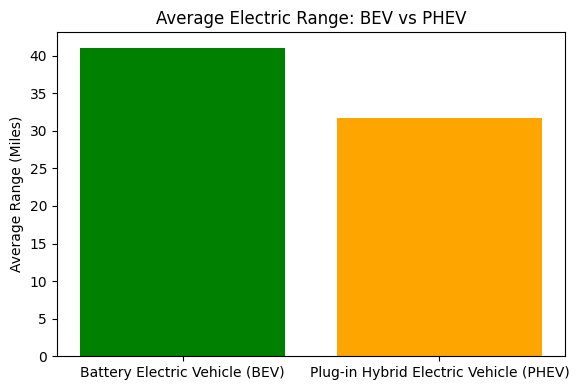

In [ ]:
# Q3: What factors distinguish BEVs from PHEVs in terms of adoption and electric range?
avg_range = ev_df.groupby("Electric Vehicle Type")["Electric Range"].mean().reset_index()
print(avg_range)

fig, ax = plt.subplots(figsize=(12, 6))
plt.bar(avg_range["Electric Vehicle Type"],avg_range["Electric Range"], color=["green", "orange"])
plt.title("Average Electric Range: BEV vs PHEV")
plt.ylabel("Average Range (Miles)")
plt.tight_layout()
add_labels(ax)
plt.show()


In [ ]:
#Create a new sheet base on electric range
def categorize_range(r):
  if r == 0 or pd.insa(r):
    return "Unknown / Update Pending"
  elif r <=50:
    return "Short Range (<50 mi) - Mostly PHEV"
  elif 50 < r <= 200:
    return "Mid Range (50-200 mi) - Mostly BEV"
  else:
    return "Long Range (>200) - High Tech"
print (categorize_range(0))

Unknown / Update Pending


                    Electric Vehicle Type  Vehicle_Count  Share (%)
0          Battery Electric Vehicle (BEV)         223783  80.019667
1  Plug-in Hybrid Electric Vehicle (PHEV)          55877  19.980333


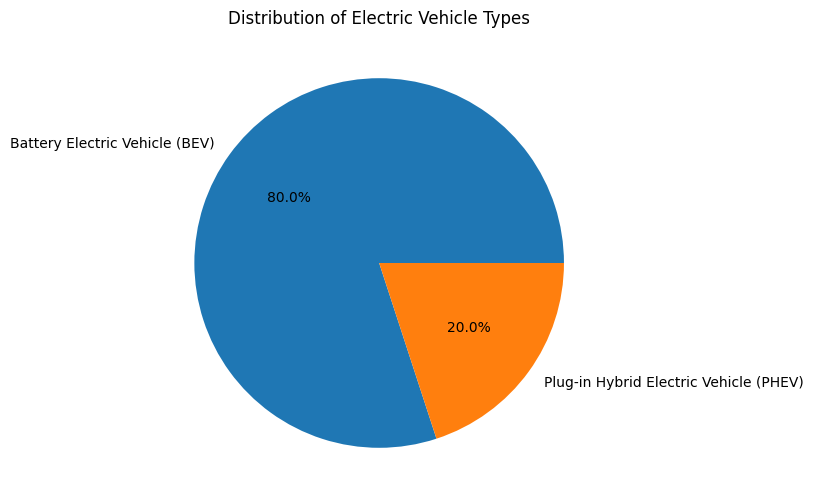

In [ ]:
# Calculate percentage share
ev_type_count = ev_df["Electric Vehicle Type"].value_counts().reset_index(name="Vehicle_Count")
total = ev_type_count["Vehicle_Count"].sum()
ev_type_count["Share (%)"] = (ev_type_count["Vehicle_Count"] / total * 100)
print(ev_type_count)

# Plot pie chart
ev_type = ev_df["Electric Vehicle Type"].value_counts()
plt.figure(figsize=(6,6))
ev_type.plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Electric Vehicle Types")
plt.ylabel("")
plt.show()

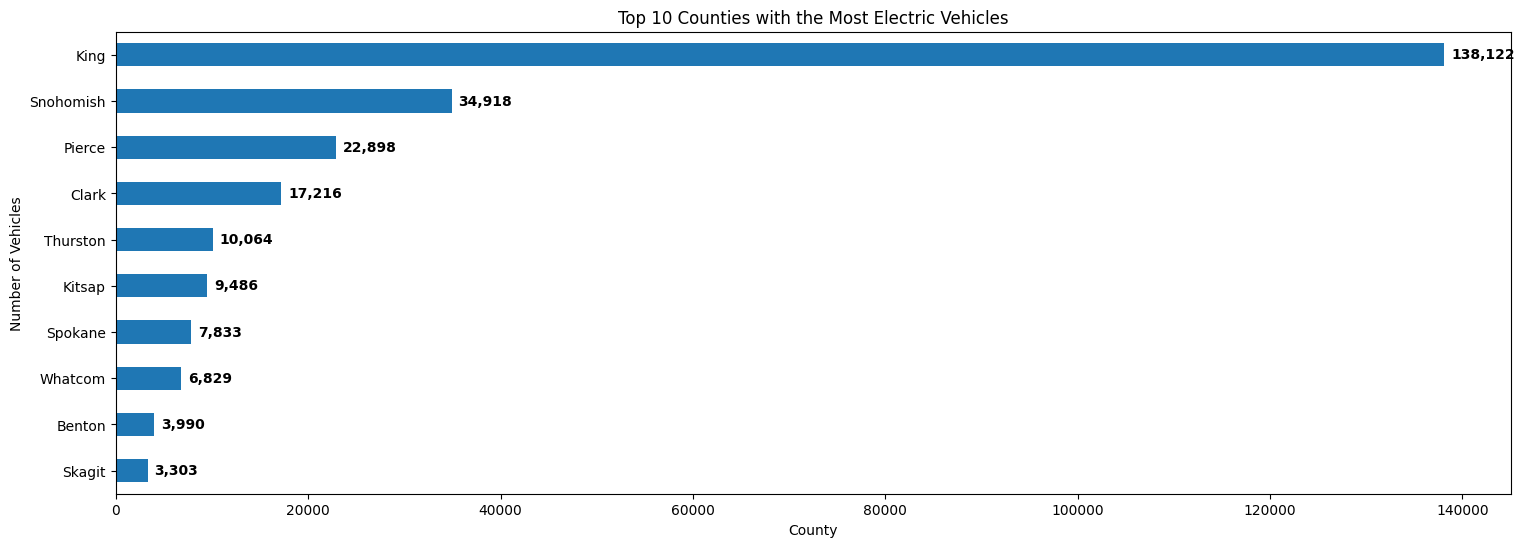

In [ ]:
# Horizontal bar chart show top 10 counties use electric vehicles
top_counties = ev_df.groupby("County").size().sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(18, 6))
top_counties.plot(kind="barh")
plt.title("Top 10 Counties with the Most Electric Vehicles")
plt.xlabel("County")
plt.ylabel("Number of Vehicles")
add_labels(ax)
plt.show()

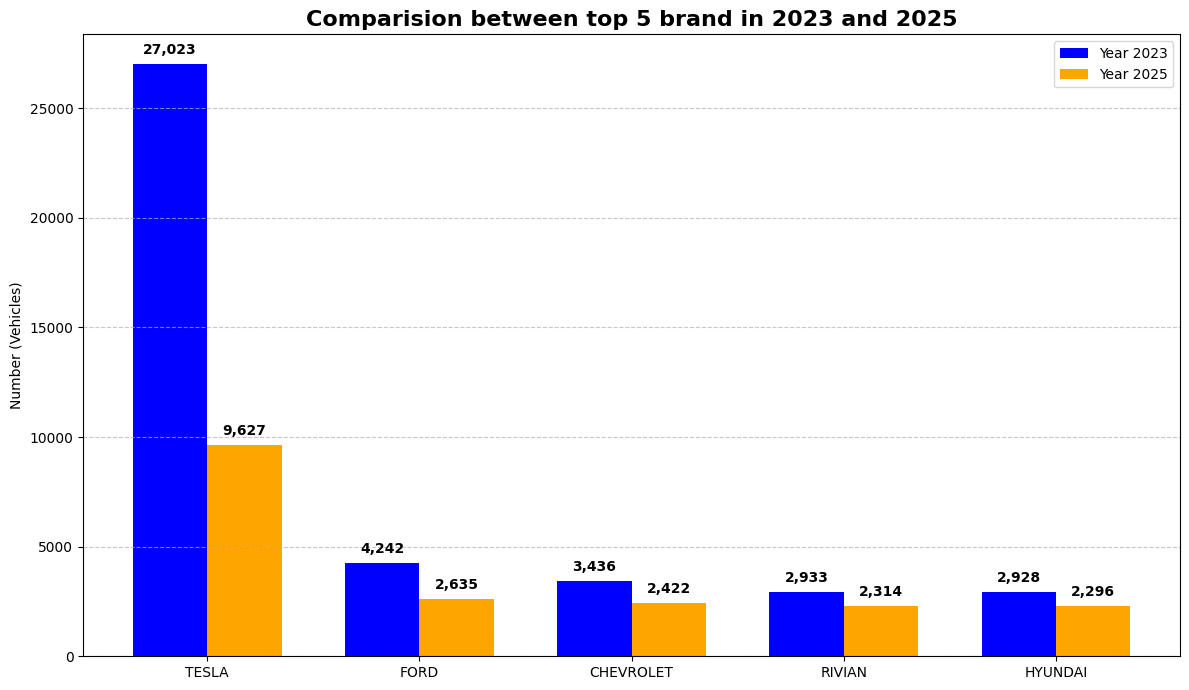

In [ ]:
# Comparision between top 5 brand in 2023 and 2025
top_2023_full = ev_df[ev_df['Model Year'] == 2023]['Make'].value_counts().head(5)
makes = top_2023_full.index.tolist()

makes_2023 = ev_df[ev_df['Model Year'] == 2023]['Make'].value_counts().head(5)
makes_2025 = ev_df[ev_df['Model Year'] == 2025]['Make'].value_counts().head(5)

x = np.arange(len(makes))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, makes_2023, width, label='Year 2023', color='blue')
rects2 = ax.bar(x + width/2, makes_2025, width, label='Year 2025', color='orange')
ax.set_ylabel('Number (Vehicles)')
ax.set_title('Comparision between top 5 brand in 2023 and 2025', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(makes)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
add_labels(ax)
plt.show()

                    Electric Vehicle Type   Count  Share_Top5 (%)  \
0          Battery Electric Vehicle (BEV)  181572       81.342902   
1  Plug-in Hybrid Electric Vehicle (PHEV)   41646       18.657098   

   Avg_Range_Top5  
0       39.354361  
1       31.652956  


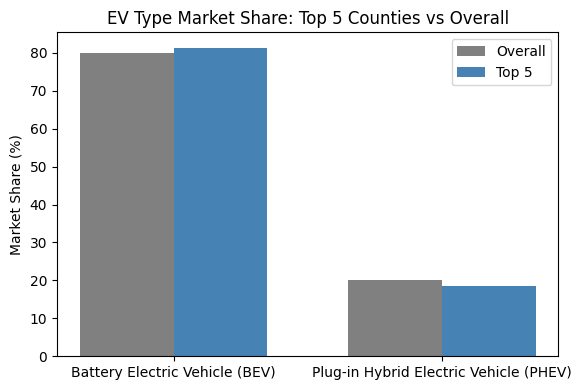

In [ ]:
top_five_counties = top_five["County"]
df_top5 = ev_df[ev_df["County"].isin(top_five_counties)]
top5_type = (df_top5.groupby("Electric Vehicle Type").size().reset_index(name="Count"))

top5_total = top5_type["Count"].sum()
top5_type["Share_Top5 (%)"] = top5_type["Count"] / top5_total * 100
top5_range = (
    df_top5.groupby("Electric Vehicle Type")["Electric Range"].mean().reset_index(name="Avg_Range_Top5"))
top5_summary = top5_type.merge(top5_range, on="Electric Vehicle Type")
print(top5_summary)

comparison = ev_type_count.merge(top5_summary, on="Electric Vehicle Type")

x = np.arange(len(comparison["Electric Vehicle Type"]))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, comparison["Share (%)"], width, label="Overall", color="gray")
plt.bar(x + width/2, comparison["Share_Top5 (%)"], width, label="Top 5", color="steelblue")
plt.xticks(x, comparison["Electric Vehicle Type"])
plt.ylabel("Market Share (%)")
plt.title("EV Type Market Share: Top 5 Counties vs Overall")
plt.legend()
plt.tight_layout()
plt.show()

Make
TESLA         41.053064
CHEVROLET      6.881570
NISSAN         5.778803
FORD           5.480941
KIA            4.983551
TOYOTA         4.228349
BMW            4.150397
HYUNDAI        3.702353
RIVIAN         3.167775
VOLKSWAGEN     2.657155
Name: count, dtype: float64


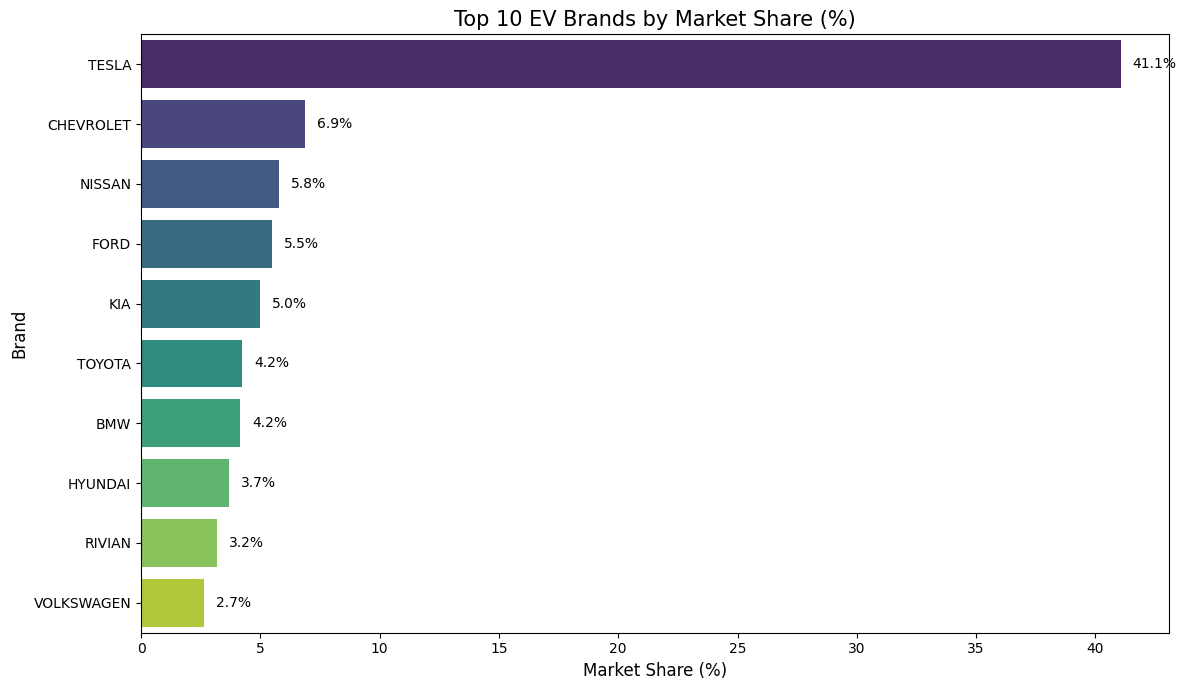

In [ ]:
# Q4: Brand Market Share
brand_counts = ev_df['Make'].value_counts()
brand_shares = (brand_counts / len(ev_df) * 100).head(10)

# Create the plot
plt.figure(figsize=(12, 7))
sns.barplot(x = brand_shares.values,
            y = brand_shares.index,
            hue = brand_shares.index,
            palette = 'viridis',
            legend = False)

# Add labels and title
plt.title('Top 10 EV Brands by Market Share (%)', fontsize=15)
plt.xlabel('Market Share (%)', fontsize=12)
plt.ylabel('Brand', fontsize=12)

# Add value labels on the bars
for i, v in enumerate(brand_shares.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('q4_market_share.png')

# Print statistics for the response
print(brand_shares)

In [ ]:
#Count the number of cars base on model years.
yearly_counts = ev_df['Model Year'].value_counts().sort_index()
yoy_growth = yearly_counts.pct_change() * 100
yoy_df = pd.DataFrame({
    "Total Vehicles": yearly_counts,
    "YoY Growth": yoy_growth
}).loc[2020:2026]
print(yoy_df)

            Total Vehicles  YoY Growth
Model Year                            
2020                 12089   11.388556
2021                 20939   73.207048
2022                 29991   43.230336
2023                 60219  100.790237
2024                 49917  -17.107557
2025                 37000  -25.876956
2026                 17396  -52.983784


In [ ]:
utility_analysis = ev_df['Electric Utility'].value_counts().head(10).reset_index()
utility_analysis.columns = ['Electric_Utility', 'Vehicle_Count']

total_top_utility = utility_analysis['Vehicle_Count'].sum()
utility_analysis['Market_Share_Percentage'] = (utility_analysis['Vehicle_Count'] / total_top_utility) * 100

print(utility_analysis)

                                    Electric_Utility  Vehicle_Count  \
0      PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)          99555   
1                             PUGET SOUND ENERGY INC          58831   
2       CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)          46458   
3  BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...          16802   
4  BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...          12730   
5  PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...           6435   
6  BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...           4796   
7  BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...           2639   
8                                         PACIFICORP           2478   
9  BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...           2335   

   Market_Share_Percentage  
0                39.340628  
1                23.247938  
2                18.358565  
3                 6.639558  
4                 5.030447  
5                 2.542885  
6              

In [ ]:
ev_df.to_excel('Cleaned_EV_Data_Project.xlsx', index=False)